In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

# Load and preprocess data

In [2]:
df = pd.read_csv("C:/Users/vedan/OneDrive/Desktop/ariculture/Dataset/crop_yield.csv")
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Encode categorical variables

In [3]:
label_encoders = {}
for col in ['Crop', 'Season', 'State']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Prepare features and target

In [4]:
X = df.drop(columns=['Yield', 'Crop_Year', 'Production'])
y = df['Yield']
feature_names = X.columns.tolist()

# Train-test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimize Random Forest

In [7]:
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

print("Best Random Forest Parameters:", rf_grid.best_params_)

Best Random Forest Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}



# Optimize Gradient Boosting

In [8]:
gb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)
gb_best = gb_grid.best_estimator_

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)

Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}


# Create weighted ensemble

In [9]:
ensemble = VotingRegressor([
    ('rf', rf_best),
    ('gb', gb_best)
], weights=[0.5, 0.5])


# Train ensemble

In [10]:
ensemble.fit(X_train_scaled, y_train)

VotingRegressor(estimators=[('rf',
                             RandomForestRegressor(max_depth=15,
                                                   max_features='sqrt',
                                                   n_estimators=200,
                                                   random_state=42)),
                            ('gb',
                             GradientBoostingRegressor(learning_rate=0.05,
                                                       max_depth=5,
                                                       min_samples_leaf=2,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42,
                                                       subsample=0.8))],
                weights=[0.5, 0.5])

# Evaluate individual models and ensemble

In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Training metrics
    train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    
    # Test metrics
    test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    print(f"\n{model_name} Performance:")
    print(f"Training - MAE: {train_mae:.2f}, R2: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
    print(f"Testing  - MAE: {test_mae:.2f}, R2: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
    
    return test_pred

# Evaluate all models

In [12]:
rf_pred = evaluate_model(rf_best, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")
gb_pred = evaluate_model(gb_best, X_train_scaled, X_test_scaled, y_train, y_test, "Gradient Boosting")
ensemble_pred = evaluate_model(ensemble, X_train_scaled, X_test_scaled, y_train, y_test, "Ensemble")


Random Forest Performance:
Training - MAE: 6.80, R2: 0.9916, RMSE: 80.12
Testing  - MAE: 18.63, R2: 0.9499, RMSE: 200.26

Gradient Boosting Performance:
Training - MAE: 4.41, R2: 0.9991, RMSE: 26.52
Testing  - MAE: 13.04, R2: 0.9698, RMSE: 155.54

Ensemble Performance:
Training - MAE: 5.10, R2: 0.9970, RMSE: 47.54
Testing  - MAE: 14.34, R2: 0.9717, RMSE: 150.46


In [13]:
def plot_feature_importance(rf_model, gb_model, feature_names):
    rf_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    gb_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Random Forest feature importance
    sns.barplot(data=rf_importance, x='importance', y='feature', ax=ax1)
    ax1.set_title('Random Forest Feature Importance')
    
    # Gradient Boosting feature importance
    sns.barplot(data=gb_importance, x='importance', y='feature', ax=ax2)
    ax2.set_title('Gradient Boosting Feature Importance')
    
    plt.tight_layout()
    plt.show()




# Plot feature importance

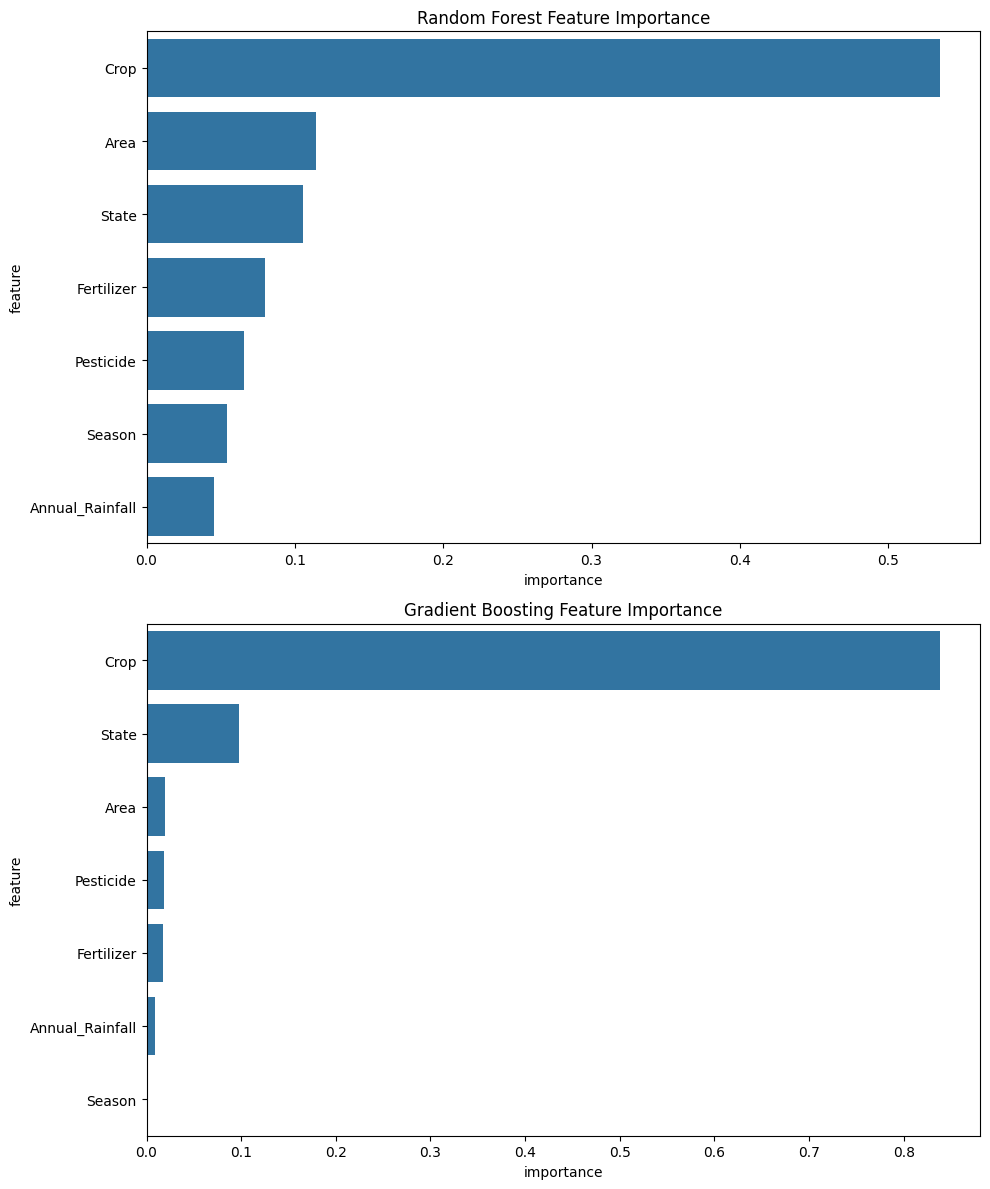

In [14]:
plot_feature_importance(rf_best, gb_best, feature_names)

# Prediction visualization

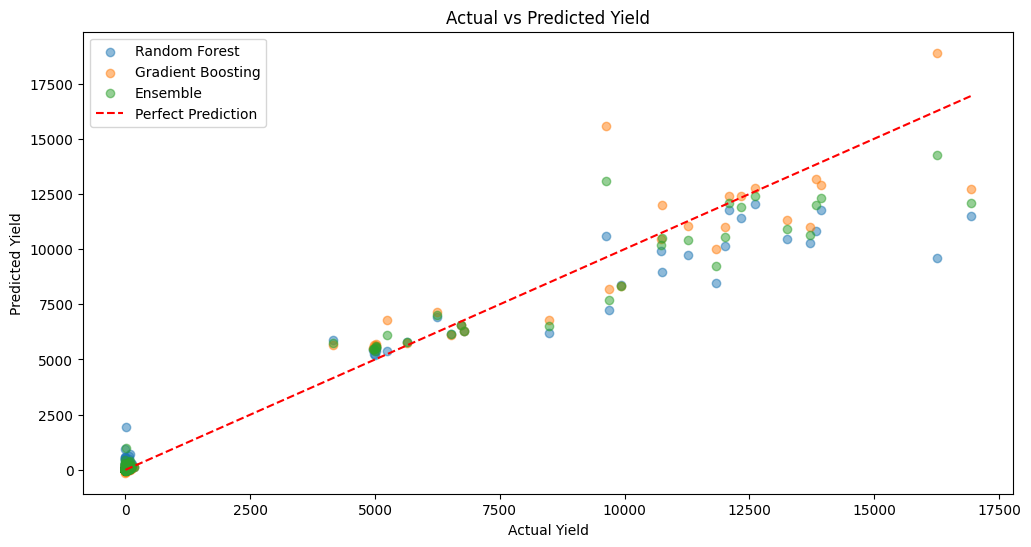

In [15]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, label='Random Forest')
plt.scatter(y_test, gb_pred, alpha=0.5, label='Gradient Boosting')
plt.scatter(y_test, ensemble_pred, alpha=0.5, label='Ensemble')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.legend()
plt.show()

# Enhanced prediction function

In [16]:
def predict_best_crop(state, season, area, rainfall, fertilizer, pesticide):
    """
    Predict best crops using the ensemble model
    """
    state_enc = label_encoders['State'].transform([state])[0]
    season_enc = label_encoders['Season'].transform([season])[0]
    predictions = []
    
    for crop in label_encoders['Crop'].classes_:
        crop_enc = label_encoders['Crop'].transform([crop])[0]
        features = pd.DataFrame([[crop_enc, season_enc, state_enc, area, rainfall, fertilizer, pesticide]], 
                              columns=feature_names)
        features_scaled = scaler.transform(features)
        
        # Get predictions from all models
        rf_prediction = rf_best.predict(features_scaled)[0]
        gb_prediction = gb_best.predict(features_scaled)[0]
        ensemble_prediction = ensemble.predict(features_scaled)[0]
        
        predictions.append({
            'crop': crop,
            'rf_yield': rf_prediction,
            'gb_yield': gb_prediction,
            'ensemble_yield': ensemble_prediction,
            'confidence': 1 - abs(rf_prediction - gb_prediction) / ((rf_prediction + gb_prediction) / 2)
        })
    
    # Sort by ensemble prediction and confidence
    predictions = sorted(predictions, 
                       key=lambda x: (x['ensemble_yield'], x['confidence']), 
                       reverse=True)
    
    return predictions[:3]

# Example prediction

In [17]:
example_prediction = predict_best_crop("Assam", "Kharif", 1000, 2000, 500, 50)
print("\nTop 3 Recommended Crops:")
for pred in example_prediction:
    print(f"\nCrop: {pred['crop']}")
    print(f"Predicted Yield: {pred['ensemble_yield']:.2f}")
    print(f"Confidence: {pred['confidence']:.2%}")


Top 3 Recommended Crops:

Crop: Coconut
Predicted Yield: 659.63
Confidence: 26.38%

Crop: Coriander
Predicted Yield: 202.44
Confidence: 0.17%

Crop: Oilseeds total
Predicted Yield: 185.28
Confidence: 11.63%


In [18]:
import joblib
import pickle
import os
output_dir = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(rf_best, os.path.join(output_dir, "rf_model.pkl"))
joblib.dump(gb_best, os.path.join(output_dir, "gb_model.pkl"))

# Save Label Encoders
with open(os.path.join(output_dir, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)

# Save Scaler
with open(os.path.join(output_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)